In [1]:
from src.ingestion import load_ehr
from src.preprocessing import lowercase_columns, remove_whitespace,  normalize_clinical_tables
from src.ehr_integration import merge_dataframes, convert_dates, calculate_age_at_onset, rename_columns
from src.visualization import (plot_distributions, double_barplot, labeled_barplot, horizontal_barplot, genotype_distribution, correlation_analysis, 
        plot_reactions, gender_severity, gender_severity, plot_urticaria_genotype, plot_severity_genotype, violin_plot, regplot)
from src.feature_engineering import wide_to_long, map_category, create_patient_core, create_one_hot_encoding
from src.genotype_generation import compute_patient_risk_multiplier, simulate_genotype, create_genotype_data, calculate_genotype_risk
from src.statistical_modeling import chi_square_test, logistic_regression, genetic_risk_score_logistic, ordinal_regression, spearman_correlation_burden

# Ingestion

In [2]:
# location of ehr files
allergies_path = 'C:/Users/tanya/projects/clinical-genomic-analytics/data/raw/allergies.csv'
patients_path = 'C:/Users/tanya/projects/clinical-genomic-analytics/data/raw/patients.csv'

# Preprocessing

In [3]:
# create dataframes for each table
allergies_df = load_ehr(allergies_path)
patients_df = load_ehr(patients_path,usecols=["Id", "BIRTHDATE", "RACE", "GENDER"])

In [4]:
# convert column names to loser case
patients_df = lowercase_columns(patients_df)
allergies_df = lowercase_columns(allergies_df)
patients_df = patients_df.drop_duplicates(subset=['id'])

In [5]:
# remove leading and trailing whitespace
allergies_df = remove_whitespace(allergies_df)
patients_df = remove_whitespace(patients_df)

In [6]:
# normalize tables: add active column, standardize patient_id column name and normalize race formatting
allergies_df, patients_df = normalize_clinical_tables(
    allergies_df,
    patients_df
)

In [7]:
# Validation schema
print("\n" + "="*60)
print("PATIENTS TABLE INFO")
print("="*60)
patients_df.info()

print("\n" + "="*60)
print("ALLERGIES TABLE INFO")
print("="*60)
allergies_df.info()


PATIENTS TABLE INFO
<class 'pandas.DataFrame'>
RangeIndex: 1163 entries, 0 to 1162
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   patient_id  1163 non-null   str  
 1   birthdate   1163 non-null   str  
 2   race        1163 non-null   str  
 3   gender      1163 non-null   str  
dtypes: str(4)
memory usage: 36.5 KB

ALLERGIES TABLE INFO
<class 'pandas.DataFrame'>
RangeIndex: 794 entries, 0 to 793
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   start         794 non-null    str    
 1   patient_id    794 non-null    str    
 2   encounter     794 non-null    str    
 3   code          794 non-null    int64  
 4   system        794 non-null    str    
 5   description   794 non-null    str    
 6   type          794 non-null    str    
 7   category      794 non-null    str    
 8   reaction1     410 non-null    float64
 9   description1  410 n

In [8]:
# EHR Data Integration

In [9]:
ehr_df = merge_dataframes(allergies_df, patients_df, 'patient_id', 
                          columns_to_add = ["patient_id", "birthdate", "race", "gender"])
ehr_df = convert_dates(ehr_df)
ehr_df = calculate_age_at_onset(ehr_df)
ehr_df = rename_columns(ehr_df)

In [10]:
# Validation schema
print("\n" + "="*60)
print("Integrated EHR Table")
print("="*60)
ehr_df.info()

print("\n" + "="*60)
ehr_df.head()


Integrated EHR Table
<class 'pandas.DataFrame'>
RangeIndex: 794 entries, 0 to 793
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   start         794 non-null    datetime64[us]
 1   patient_id    794 non-null    str           
 2   encounter     794 non-null    str           
 3   code          794 non-null    int64         
 4   system        794 non-null    str           
 5   allergen      794 non-null    str           
 6   type          794 non-null    str           
 7   category      794 non-null    str           
 8   reaction1     410 non-null    float64       
 9   description1  410 non-null    str           
 10  severity1     410 non-null    str           
 11  reaction2     259 non-null    float64       
 12  description2  259 non-null    str           
 13  severity2     259 non-null    str           
 14  active        794 non-null    object        
 15  birthdate     794 non-null   

,start,patient_id,encounter,code,system,allergen,type,category,reaction1,description1,severity1,reaction2,description2,severity2,active,birthdate,race,gender,age
0,2020-02-17,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,01efcc52-15d6-51e9-faa2-bee069fcbe44,111088007,Unknown,Latex (substance),allergy,environment,247472004.0,Wheal (finding),MILD,NaN,NaN,NaN,yes,2019-02-17,white,M,1
1,2020-02-17,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,01efcc52-15d6-51e9-faa2-bee069fcbe44,84489001,Unknown,Mold (organism),allergy,environment,76067001.0,Sneezing,MILD,NaN,NaN,NaN,yes,2019-02-17,white,M,1
2,2020-02-17,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,01efcc52-15d6-51e9-faa2-bee069fcbe44,260147004,Unknown,House dust mite (organism),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN,yes,2019-02-17,white,M,1
3,2020-02-17,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,01efcc52-15d6-51e9-faa2-bee069fcbe44,264287008,Unknown,Animal dander (substance),allergy,environment,878820003.0,Rhinoconjunctivitis (disorder),MODERATE,271807003.0,Eruption of skin (disorder),MILD,yes,2019-02-17,white,M,1
4,2020-02-17,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,01efcc52-15d6-51e9-faa2-bee069fcbe44,256277009,Unknown,Grass pollen (substance),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN,yes,2019-02-17,white,M,1


# EHR DATA EXPLORATORY DATA ANALYSIS (EDA)

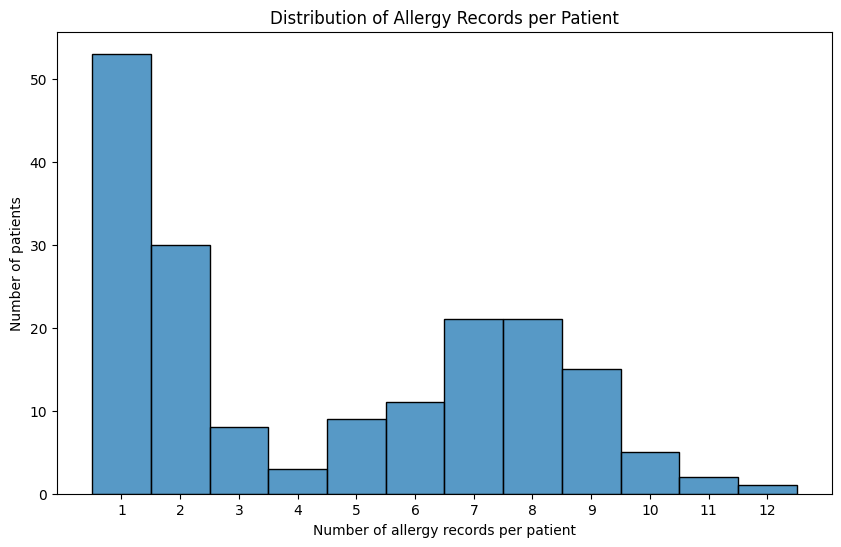

In [11]:
# Analyze distribution of allergy records per patient
# This helps identify patients with multiple allergy episodes

plot_distributions(ehr_df, "patient_id", "Distribution of Allergy Records per Patient", 
                   "Number of allergy records per patient","Number of patients", count_distribution=True)

In [12]:
# Analyze allergy categories by patient counts and total records
# This helps understand the prevalence and frequency of different allergy types

category_summary = ehr_df.groupby("category").agg(
            n_patients=("patient_id", "nunique"),
            n_records=("patient_id", "size")
        ).reset_index().melt(
            id_vars='category',
            var_name='Metric',
            value_name='Count'
        )
print("\n" + "="*60)
print("Count of patients and records by allergy category")
print("="*60)
display(category_summary)



Count of patients and records by allergy category


,category,Metric,Count
0,environment,n_patients,123
1,food,n_patients,139
2,medication,n_patients,59
3,environment,n_records,492
4,food,n_records,234
5,medication,n_records,68


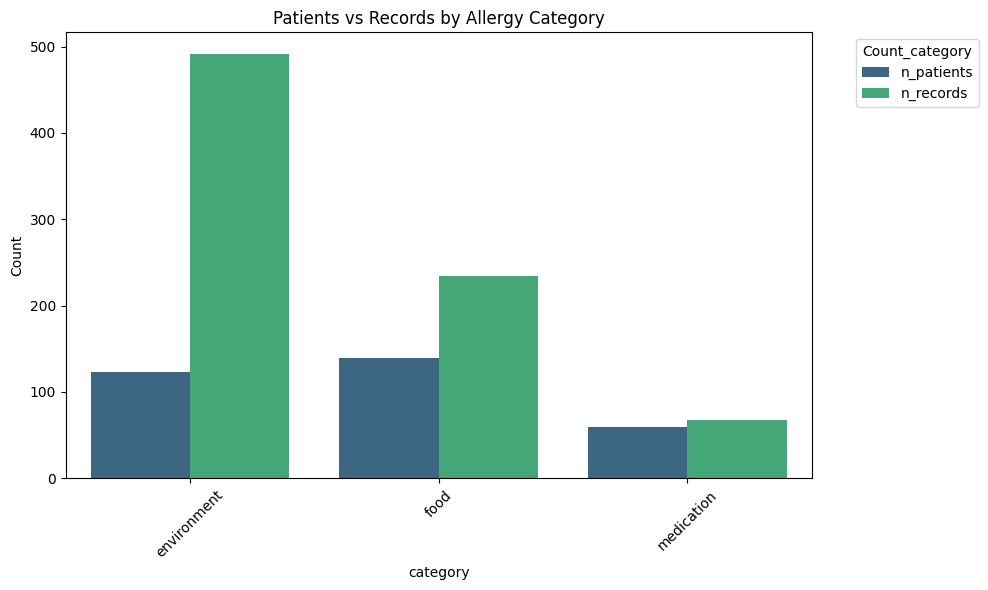

In [13]:
double_barplot(category_summary, 'category', 'Count','Metric', 'Patients vs Records by Allergy Category','Count_category')


=== CATEGORICAL VARIABLE DISTRIBUTIONS ===


Distribution of category:



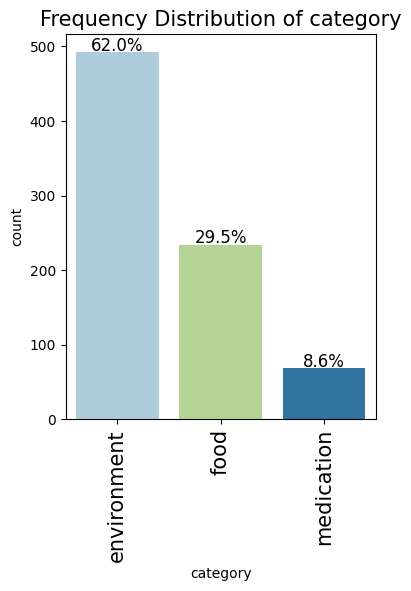



Distribution of allergen:



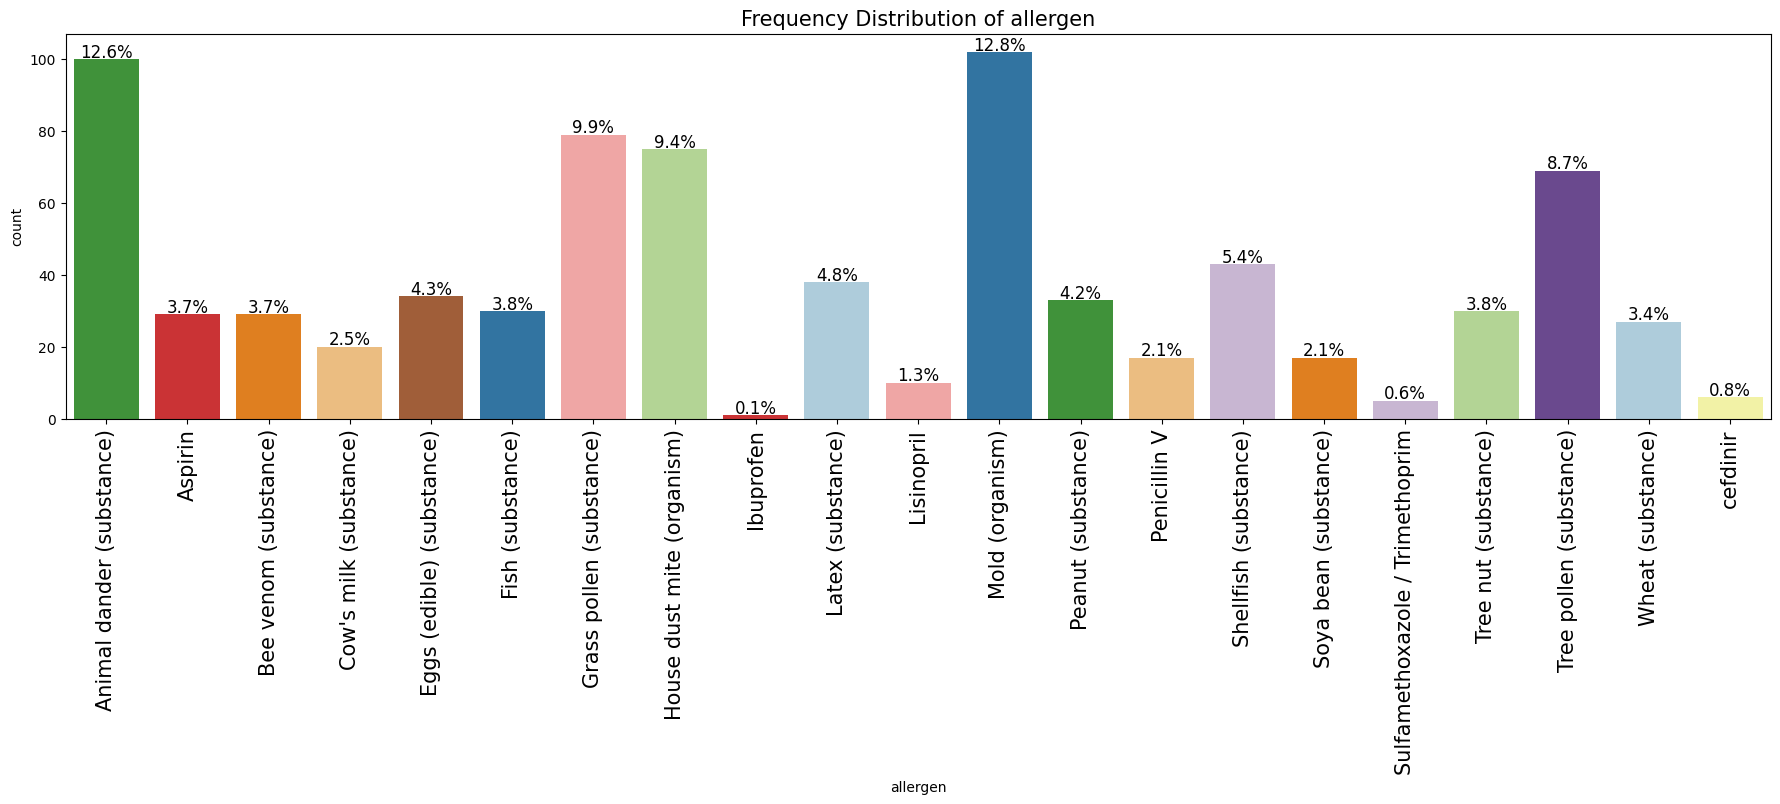



Distribution of type:



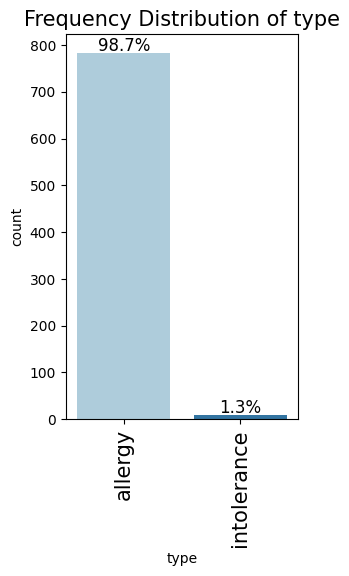

In [14]:
# Visualize frequency distributions for key categorical variables
print("\n=== CATEGORICAL VARIABLE DISTRIBUTIONS ===")
for feature in ['category', 'allergen', 'type']:
    print("\n" + "="*60)
    print(f"\nDistribution of {feature}:")
    print("\n" + "="*60)
    labeled_barplot(ehr_df, feature, perc=True)




Top 10 Allergens



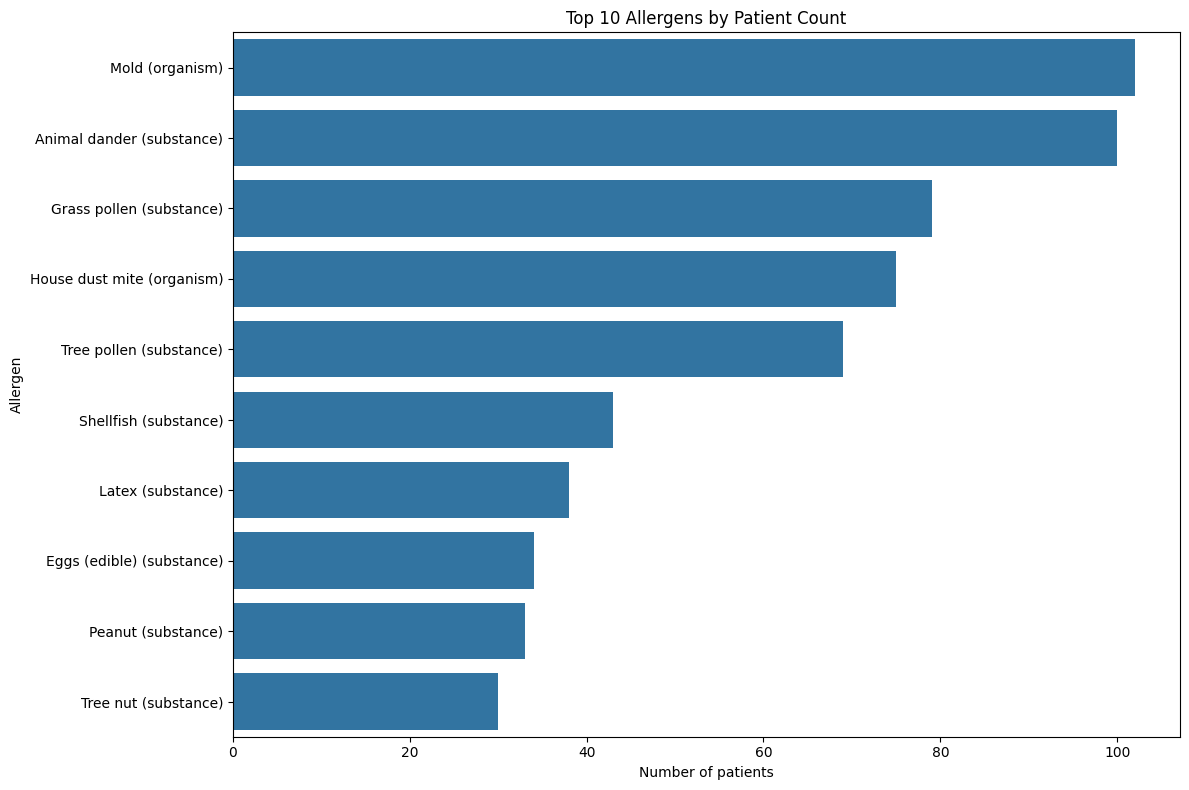

In [15]:
# Identify and visualize top 10 most common allergens by patient count
top_allergens = (
    ehr_df.groupby("allergen")["patient_id"]
       .nunique()
       .sort_values(ascending=False)
       .head(10)
       .reset_index(name="n_patients")
)
print("\n" + "="*60)
print(f"\nTop 10 Allergens")
print("\n" + "="*60)
horizontal_barplot(top_allergens, "n_patients", "allergen", "Number of patients", "Allergen", "Top 10 Allergens by Patient Count")



Racial distribution



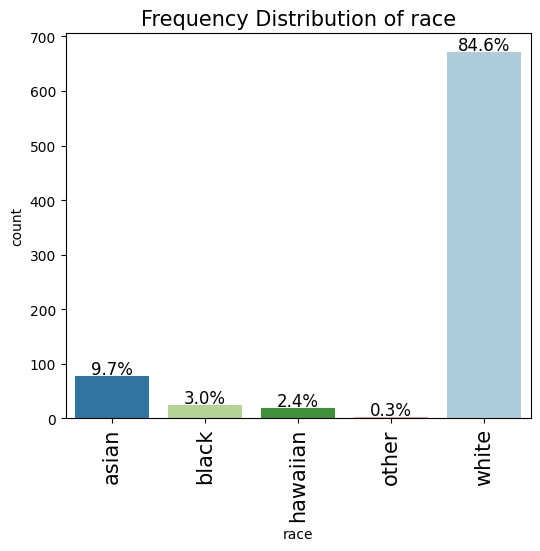

In [16]:
# Visualize racial distribution in the dataset
print("\n" + "="*60)
print(f"\nRacial distribution")
print("\n" + "="*60)
labeled_barplot(ehr_df, 'race', perc=True)

# Feature Engineering

## Convert EHR table to long format

In [17]:
# convert ehr table to long format
ehr_long = wide_to_long(ehr_df)

In [18]:
print("\nTransformed dataset info:")
ehr_long.info()


Transformed dataset info:
<class 'pandas.DataFrame'>
Index: 1204 entries, 0 to 1587
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   start        1204 non-null   datetime64[us]
 1   patient_id   1204 non-null   str           
 2   encounter    1204 non-null   str           
 3   allergen     1204 non-null   str           
 4   type         1204 non-null   str           
 5   category     1204 non-null   str           
 6   record_id    1204 non-null   int64         
 7   active       1204 non-null   object        
 8   age          1204 non-null   Int64         
 9   birthdate    1204 non-null   datetime64[us]
 10  gender       1204 non-null   str           
 11  race         1204 non-null   str           
 12  reaction     669 non-null    float64       
 13  description  669 non-null    str           
 14  severity     669 non-null    str           
dtypes: Int64(1), datetime64[us](2), float64(1), 



=== REACTION DISTRIBUTIONS ===



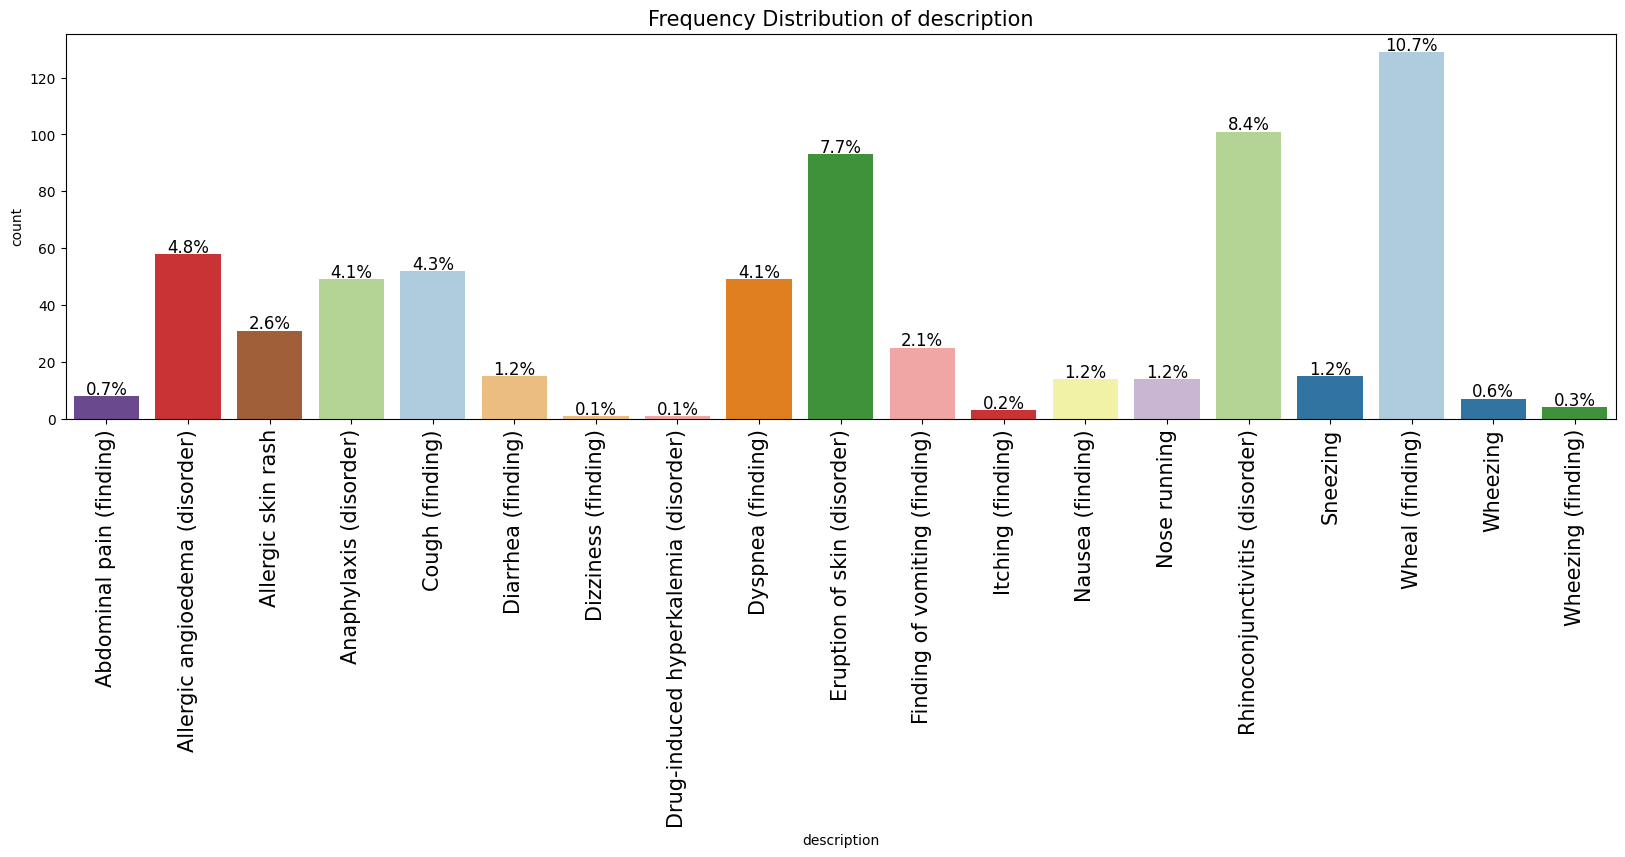

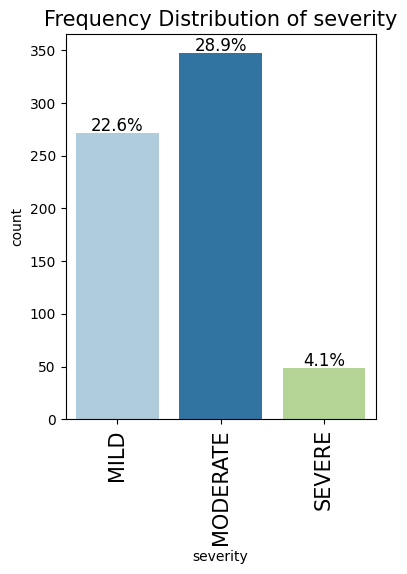

In [19]:
print("\n" + "="*60)
print("\n=== REACTION DISTRIBUTIONS ===")
print("\n" + "="*60)
for feature in ['description', 'severity']:
    labeled_barplot(ehr_long, feature, perc=True)

## Convert severity to numeric and create categories for reactions

In [20]:
# Define severity mapping for numerical analysis
# Converting categorical severity to ordinal scale (1=Mild, 2=Moderate, 3=Severe)
severity_mapping = {
    "MILD": 1,
    "MODERATE": 2,
    "SEVERE": 3
}

In [21]:
# Categorize reactions
reaction_category_map =  {
    "urticaria": [
        "Wheal (finding)",
        "Allergic angioedema (disorder)"
    ],
    "skin_problems": [
        "Eruption of skin (disorder)",
        "Allergic skin rash",
        "Itching (finding)"
    ],
    "upper_respiratory": [
        "Sneezing",
        "Nose running",
        "Rhinoconjunctivitis (disorder)",
    ],
    "lower_respiratory": [
        "Cough (finding)",
        "Wheezing",
        "Wheezing (finding)",
        "Dyspnea (finding)"
    ],
    "anaphylaxis": [
        "Anaphylaxis (disorder)"
    ],
    "gi_symptoms": [
        "Nausea (finding)",
        "Finding of vomiting (finding)",
        "Diarrhea (finding)",
        "Abdominal pain (finding)"
    ],
    "systemic": [
        "Dizziness (finding)",
        "Drug-induced hyperkalemia (disorder)"
    ]

}

In [22]:
# create numeric column for severity
ehr_long = map_category(ehr_long, "severity","severity_numeric", severity_mapping)

In [23]:
# create categories for reactions based on the reaction_category_map
ehr_long = map_category(ehr_long, "description", "reaction_category", reaction_category_map)

In [24]:
print("\n=== REACTION CATEGORIZATION ===")
print("Unique reaction categories:")
print(ehr_long["reaction_category"].dropna().unique())


=== REACTION CATEGORIZATION ===
Unique reaction categories:
<StringArray>
[        'urticaria', 'upper_respiratory',     'skin_problems',
       'gi_symptoms', 'lower_respiratory',       'anaphylaxis',
          'systemic']
Length: 7, dtype: str


## Create patient-level aggregation

In [25]:
# create patient-level dataframe with one record per patient with count of allergy records, number of unique allergens and max severity.
patient_core = create_patient_core(ehr_long)

Available severity columns: ['severity', 'severity_numeric']

Column 'severity' sample values:
severity
NaN         535
MODERATE    348
MILD        272
SEVERE       49
Name: count, dtype: int64
Unique values: <StringArray>
['MILD', nan, 'MODERATE', 'SEVERE']
Length: 4, dtype: str
Data type: str

Column 'severity_numeric' sample values:
severity_numeric
NaN    535
2.0    348
1.0    272
3.0     49
Name: count, dtype: int64
Unique values: [ 1. nan  2.  3.]
Data type: float64

Using severity_numeric column
Non-null values in severity_numeric: 669


In [26]:
# create binary columns for allergy reactions and allergens
patient_core = create_one_hot_encoding(ehr_long,  patient_core,'category', 'allergen')
patient_core = create_one_hot_encoding(ehr_long,  patient_core, 'reaction_category', 'reaction')
display(patient_core.info())

<class 'pandas.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  179 non-null    str    
 1   n_allergy_records           179 non-null    int64  
 2   n_unique_allergens          179 non-null    int64  
 3   max_severity                179 non-null    float64
 4   race                        179 non-null    str    
 5   gender                      179 non-null    str    
 6   age_at_start                179 non-null    int64  
 7   allergen_environment        179 non-null    int64  
 8   allergen_food               179 non-null    int64  
 9   allergen_medication         179 non-null    int64  
 10  reaction_anaphylaxis        179 non-null    int64  
 11  reaction_gi_symptoms        179 non-null    int64  
 12  reaction_lower_respiratory  179 non-null    int64  
 13  reaction_skin_problems      179 non-null    in

None

In [27]:
display(patient_core.describe(include = 'all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,179,179,0142b69f-57f0-9a08-4e2d-65a2b77fdea7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_allergy_records,179.0,NaN,NaN,NaN,6.726257,4.843382,1.0,2.0,6.0,11.0,20.0
n_unique_allergens,179.0,NaN,NaN,NaN,4.435754,3.237778,1.0,1.0,3.0,7.0,12.0
max_severity,179.0,NaN,NaN,NaN,1.793296,1.188314,-1.0,2.0,2.0,2.0,3.0
race,179,5,white,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,179,2,F,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_at_start,179.0,NaN,NaN,NaN,2.932961,6.130232,0.0,1.0,1.0,1.0,35.0
allergen_environment,179.0,NaN,NaN,NaN,0.687151,0.464954,0.0,0.0,1.0,1.0,1.0
allergen_food,179.0,NaN,NaN,NaN,0.776536,0.417735,0.0,1.0,1.0,1.0,1.0
allergen_medication,179.0,NaN,NaN,NaN,0.329609,0.47139,0.0,0.0,0.0,1.0,1.0


# Genetic Vairant Simulation

In [28]:
"""
According to the article in the Journal of Allergy and Clinical Immunology,
https://www.sciencedirect.com/science/article/pii/S009167492301117X
the follwoing SNPs were linked to increase chances of urticaria allergic reaction.
Baseline MAF taken from GnomAD database.
"""

snp_info = {
    "rs6703348": {"base_maf": 0.18, "effect": 1.3},
    "rs74227709": {"base_maf": 0.10, "effect": 1.5},
    "rs35834008": {"base_maf": 0.25, "effect": 1.2},
    "rs139299944": {"base_maf": 0.45, "effect": 1.1},
    "rs73141533": {"base_maf": 0.05, "effect": 1.8},
    "rs118070675": {"base_maf": 0.08, "effect": 1.6},
}

In [29]:
"""
Calculate risk multiplier based on whether or not a patient had an allergic reaction and 
whether or not that reaction was Urticaria to simulate real life scenario
"""

patient_phenotypes = patient_core.copy()
patient_phenotypes["risk_multiplier"] = patient_core.apply(
    compute_patient_risk_multiplier, axis=1
)

In [30]:
# Calculate probability of genotype by using base MAF * effect * risk multiplier
genotype_df = create_genotype_data(snp_info, patient_phenotypes)

In [31]:
print("\n" + "="*60)
print("\n=== Geotype Data Preview ===")
print("\n" + "="*60)
display(genotype_df.head())



=== Geotype Data Preview ===



,patient_id,rs6703348,rs74227709,rs35834008,rs139299944,rs73141533,rs118070675
0,0142b69f-57f0-9a08-4e2d-65a2b77fdea7,1,0,2,2,1,0
1,01d78eb5-7f50-45e9-f524-921196a3dffe,2,1,2,2,2,0
2,01f8bbfd-cfc6-3b97-8bc1-8da6f0b4a9a8,2,0,2,2,0,2
3,0288c42c-43a1-9878-4a9d-6b96caa12c40,1,1,1,2,0,0
4,02ceca12-357f-981e-dcf3-3d26d3c1ff82,0,1,1,2,1,0




=== Geotype Distribution Analysis ===



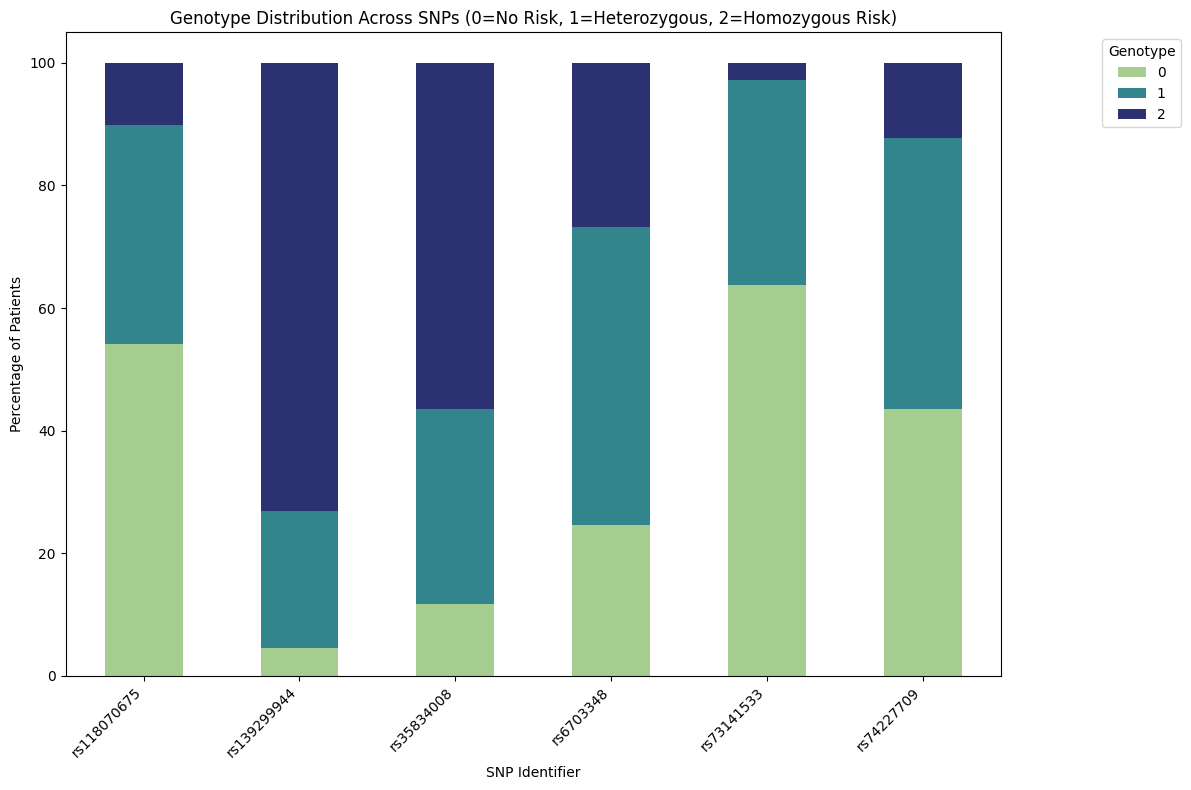

In [32]:
print("\n" + "="*60)
print("\n=== Geotype Distribution Analysis ===")
print("\n" + "="*60)
genotype_distribution(snp_info,genotype_df)

In [33]:
# Calculate genetic risk score - a single measure of genetic burden for each patient
genotype_df = calculate_genotype_risk(snp_info,genotype_df)



=== Genetic Risk Score Distribution ===



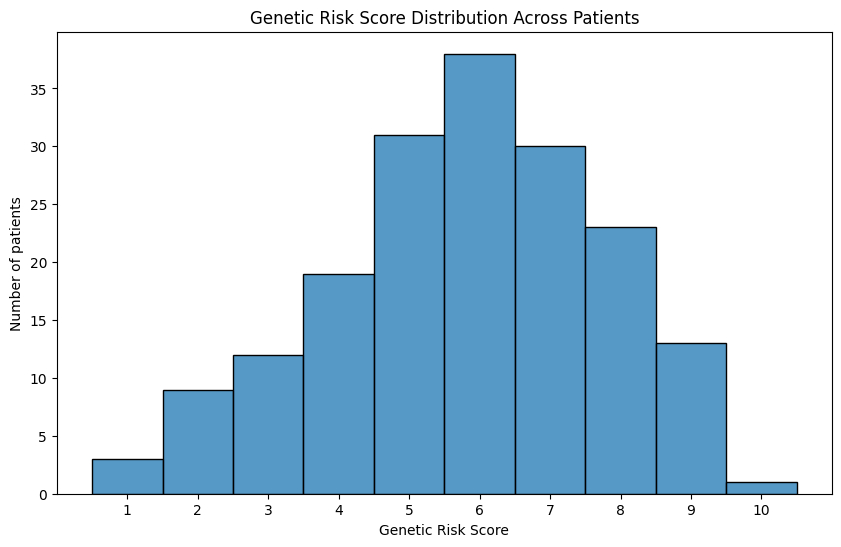

In [34]:
print("\n" + "="*60)
print("\n=== Genetic Risk Score Distribution ===")
print("\n" + "="*60)
plot_distributions(genotype_df,"genetic_risk_score", "Genetic Risk Score Distribution Across Patients", "Genetic Risk Score", "Number of patients")

# Genotype - Phenotype Data Integration

In [35]:
geno_pheno_df = merge_dataframes(patient_core, genotype_df, 'patient_id')
display(geno_pheno_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  179 non-null    str    
 1   n_allergy_records           179 non-null    int64  
 2   n_unique_allergens          179 non-null    int64  
 3   max_severity                179 non-null    float64
 4   race                        179 non-null    str    
 5   gender                      179 non-null    str    
 6   age_at_start                179 non-null    int64  
 7   allergen_environment        179 non-null    int64  
 8   allergen_food               179 non-null    int64  
 9   allergen_medication         179 non-null    int64  
 10  reaction_anaphylaxis        179 non-null    int64  
 11  reaction_gi_symptoms        179 non-null    int64  
 12  reaction_lower_respiratory  179 non-null    int64  
 13  reaction_skin_problems      179 non-null    in

None

In [36]:
display(geno_pheno_df.describe(include = 'all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,179,179,0142b69f-57f0-9a08-4e2d-65a2b77fdea7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_allergy_records,179.0,NaN,NaN,NaN,6.726257,4.843382,1.0,2.0,6.0,11.0,20.0
n_unique_allergens,179.0,NaN,NaN,NaN,4.435754,3.237778,1.0,1.0,3.0,7.0,12.0
max_severity,179.0,NaN,NaN,NaN,1.793296,1.188314,-1.0,2.0,2.0,2.0,3.0
race,179,5,white,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,179,2,F,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_at_start,179.0,NaN,NaN,NaN,2.932961,6.130232,0.0,1.0,1.0,1.0,35.0
allergen_environment,179.0,NaN,NaN,NaN,0.687151,0.464954,0.0,0.0,1.0,1.0,1.0
allergen_food,179.0,NaN,NaN,NaN,0.776536,0.417735,0.0,1.0,1.0,1.0,1.0
allergen_medication,179.0,NaN,NaN,NaN,0.329609,0.47139,0.0,0.0,0.0,1.0,1.0




=== Correlation Analysis of Genotype-Phenotype table ===



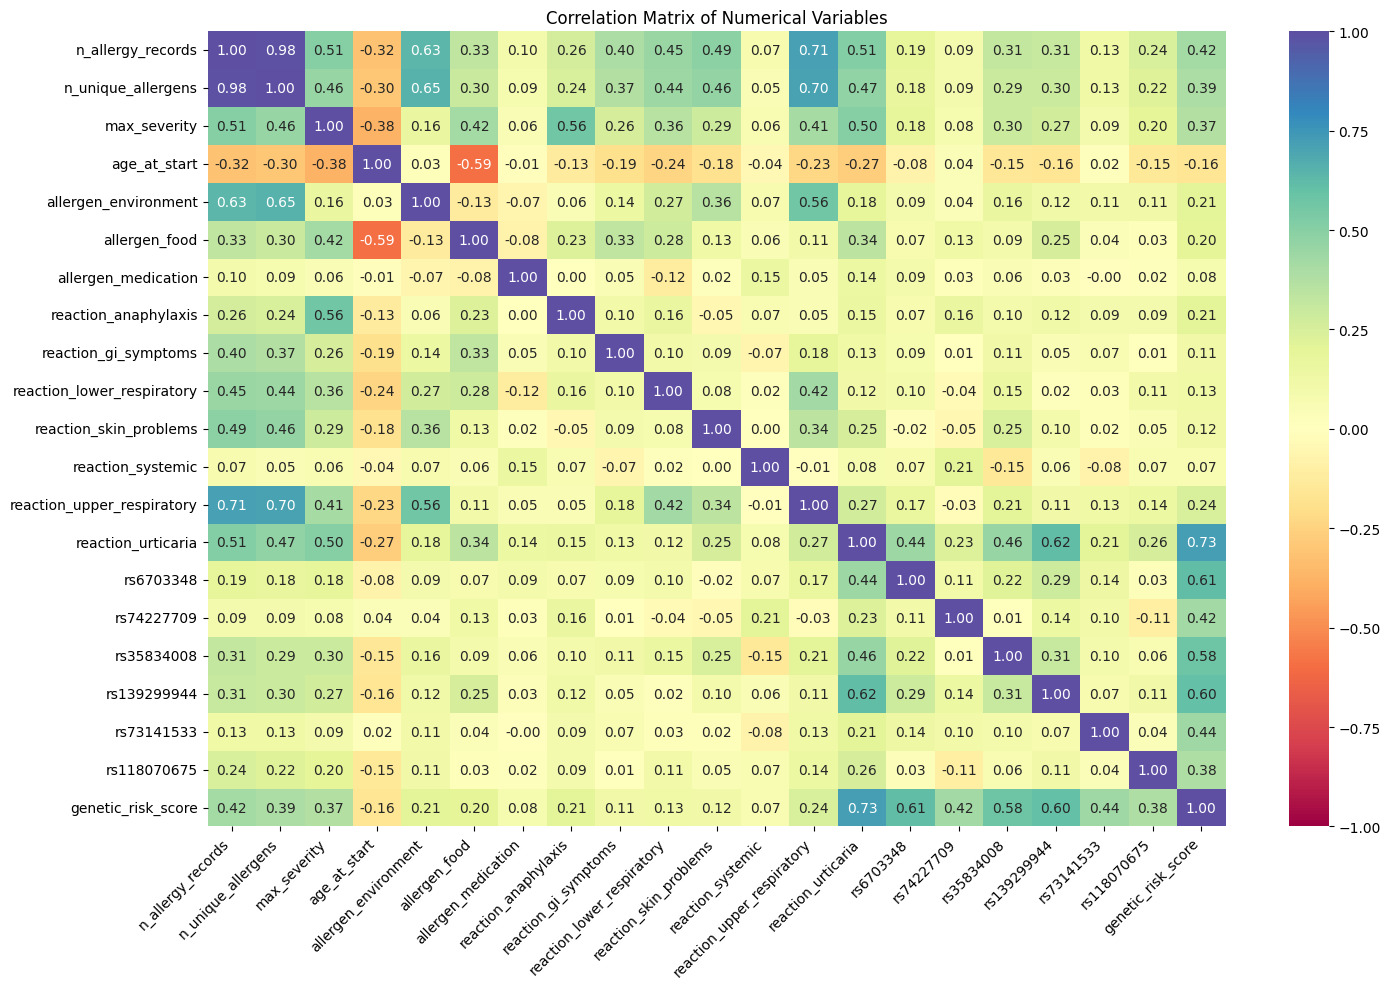

In [37]:
print("\n" + "="*60)
print("\n=== Correlation Analysis of Genotype-Phenotype table ===")
print("\n" + "="*60)
correlation_analysis(geno_pheno_df)

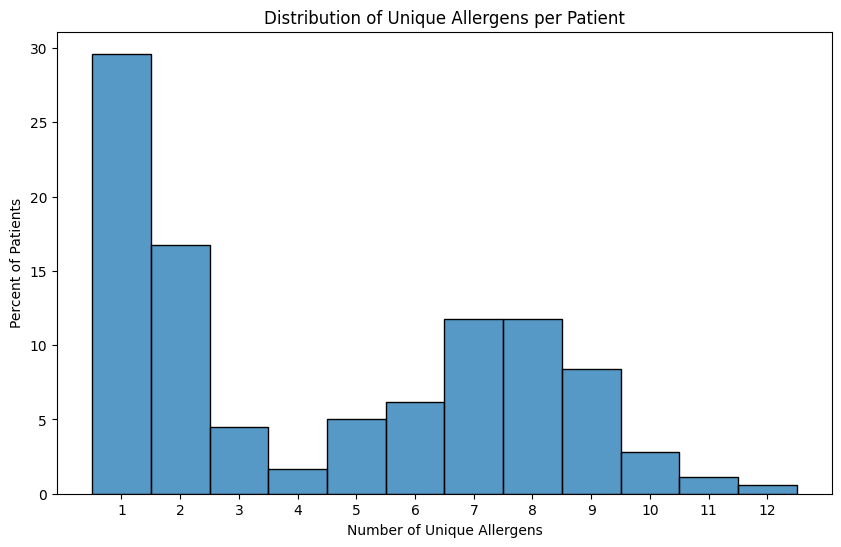

In [38]:
plot_distributions(geno_pheno_df, "n_unique_allergens", "Distribution of Unique Allergens per Patient","Number of Unique Allergens", "Percent of Patients",
                  stat = 'percent')

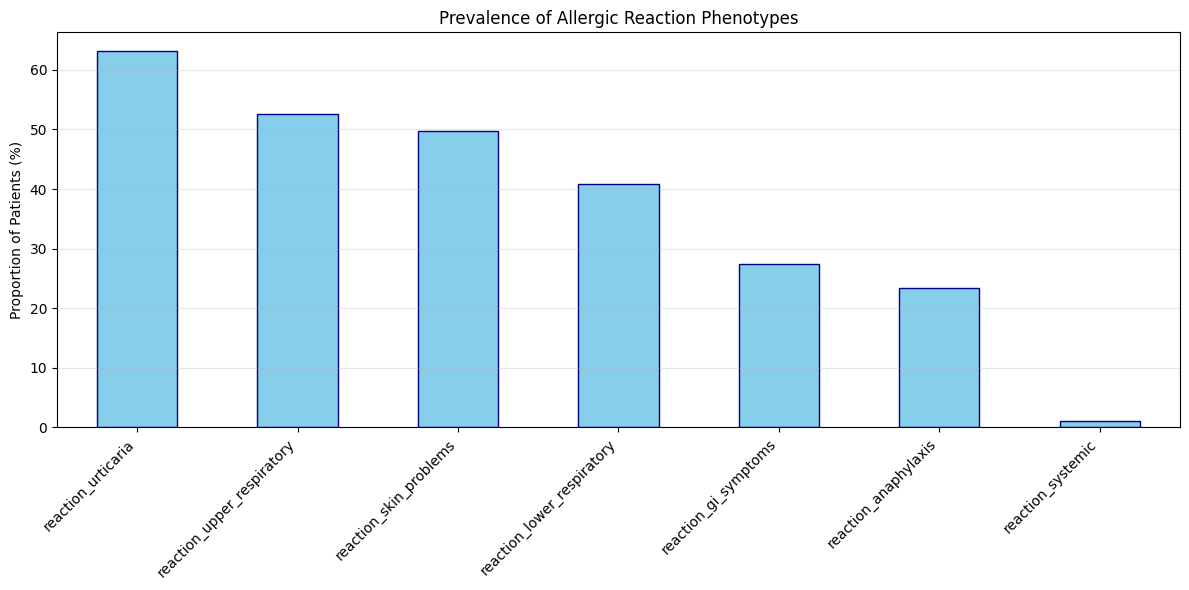

In [39]:
plot_reactions(geno_pheno_df)

In [40]:
# Display gender distribution in the combined dataset for reference
print("\n" + "="*60)
print("\n=== Gender distribution in analysis dataset ===")
print("\n" + "="*60)
gender_analysis_distribution = geno_pheno_df['gender'].value_counts()
display(gender_analysis_distribution)



=== Gender distribution in analysis dataset ===



gender
F    108
M     71
Name: count, dtype: int64

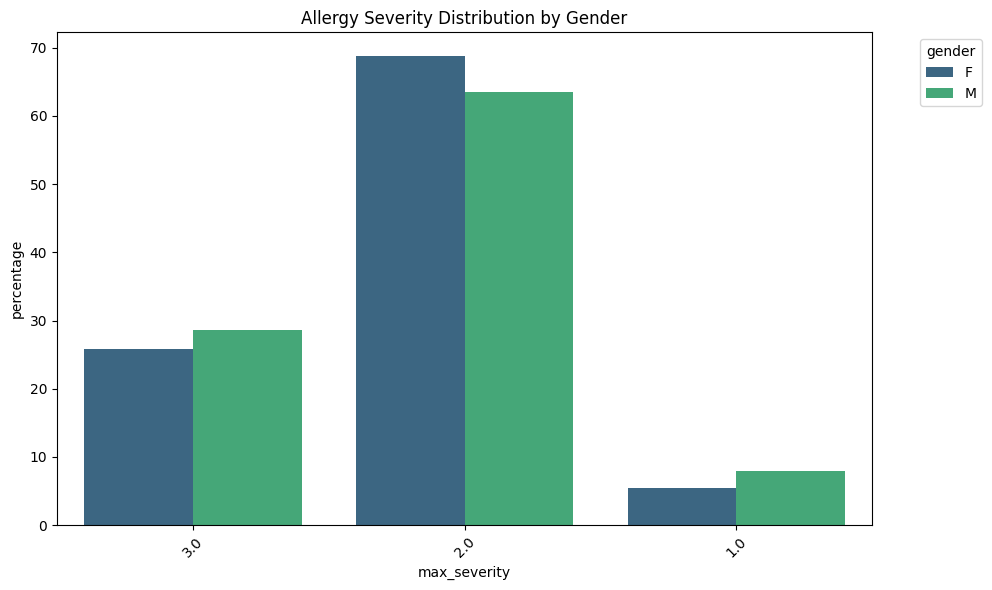

In [41]:
gender_severity(geno_pheno_df)

# Genetic Association Statistical Analysis

In [42]:
snp_list = list(snp_info.keys())

## Urticaria-genotype association

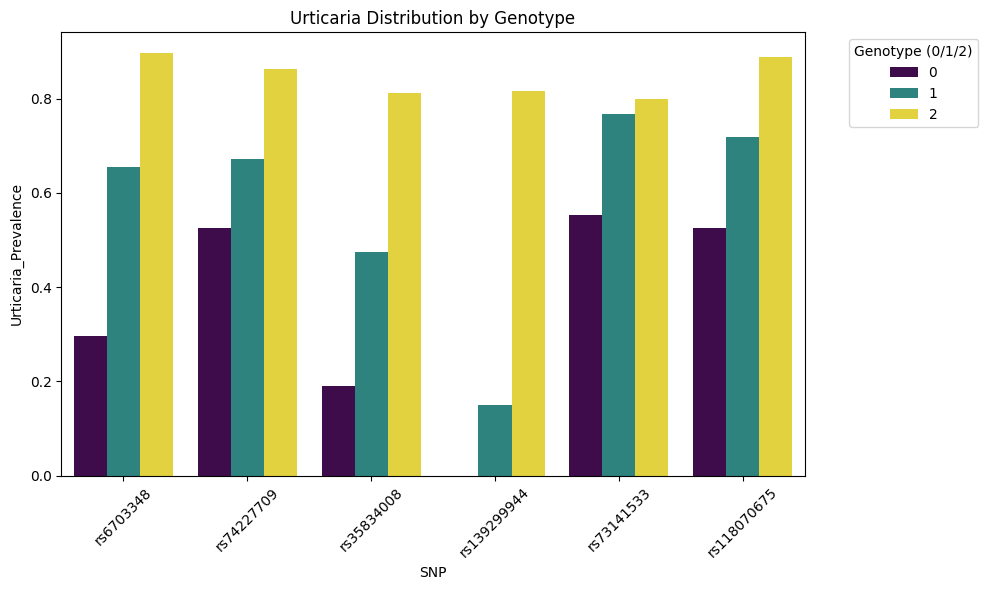

In [43]:
plot_urticaria_genotype(geno_pheno_df, snp_list)

### Chi-square tests for each SNP

In [44]:
for snp_identifier in snp_list:
    chi2_statistic, p_value, degrees_freedom, expected_frequencies = chi_square_test(geno_pheno_df, snp_identifier, 'reaction_urticaria')
    if chi2_statistic:
        print(f"SNP: {snp_identifier}")
        print(f"  Chi-square statistic: {chi2_statistic:.3f}")
        print(f"  P-value: {p_value:.4f}")
        print(f"  Degrees of freedom: {degrees_freedom}")

        # Interpret statistical significance
        if p_value < 0.05:
            print("  → Significant association detected (p < 0.05)")
        else:
            print("  → No significant association (p ≥ 0.05)")
    else:
        print(f"SNP: {snp_identifier} - Insufficient data for chi-square test")
    print()
    
    

SNP: rs6703348
  Chi-square statistic: 35.965
  P-value: 0.0000
  Degrees of freedom: 2
  → Significant association detected (p < 0.05)

SNP: rs74227709
  Chi-square statistic: 9.375
  P-value: 0.0092
  Degrees of freedom: 2
  → Significant association detected (p < 0.05)

SNP: rs35834008
  Chi-square statistic: 37.765
  P-value: 0.0000
  Degrees of freedom: 2
  → Significant association detected (p < 0.05)

SNP: rs139299944
  Chi-square statistic: 72.871
  P-value: 0.0000
  Degrees of freedom: 2
  → Significant association detected (p < 0.05)

SNP: rs73141533
  Chi-square statistic: 8.366
  P-value: 0.0153
  Degrees of freedom: 2
  → Significant association detected (p < 0.05)

SNP: rs118070675
  Chi-square statistic: 11.875
  P-value: 0.0026
  Degrees of freedom: 2
  → Significant association detected (p < 0.05)



### Logistic regression model for each SNP

In [45]:
for snp_identifier in snp_list:
    odds_ratio, p_value, confidence_interval = logistic_regression(geno_pheno_df, snp_identifier, 'reaction_urticaria')
    print(f"SNP: {snp_identifier}")
    print(f"  Odds Ratio: {odds_ratio:.3f}")
    print(f"  95% CI: [{confidence_interval[0]:.3f}, {confidence_interval[1]:.3f}]")
    print(f"  P-value: {p_value:.4f}")

    # Interpret odds ratio
    if odds_ratio > 1.0:
        print(f"  → Each additional risk allele increases odds by {(odds_ratio - 1) * 100:.1f}%")
    elif odds_ratio < 1.0:
        print(f"  → Each additional risk allele decreases odds by {(1 - odds_ratio) * 100:.1f}%")
    else:
        print("  → No effect on urticaria odds")
    print()
    

SNP: rs6703348
  Odds Ratio: 4.529
  95% CI: [2.629, 7.803]
  P-value: 0.0000
  → Each additional risk allele increases odds by 352.9%

SNP: rs74227709
  Odds Ratio: 2.114
  95% CI: [1.293, 3.456]
  P-value: 0.0028
  → Each additional risk allele increases odds by 111.4%

SNP: rs35834008
  Odds Ratio: 4.473
  95% CI: [2.640, 7.577]
  P-value: 0.0000
  → Each additional risk allele increases odds by 347.3%

SNP: rs139299944
  Odds Ratio: 25.869
  95% CI: [9.905, 67.563]
  P-value: 0.0000
  → Each additional risk allele increases odds by 2486.9%

SNP: rs73141533
  Odds Ratio: 2.434
  95% CI: [1.289, 4.596]
  P-value: 0.0061
  → Each additional risk allele increases odds by 143.4%

SNP: rs118070675
  Odds Ratio: 2.469
  95% CI: [1.452, 4.201]
  P-value: 0.0009
  → Each additional risk allele increases odds by 146.9%



### Genetic Risk Score association

In [46]:
odds_ratio, p_value, confidence_interval = genetic_risk_score_logistic(geno_pheno_df, snp_identifier, 'reaction_urticaria')

print(f"\nInterpretation:")
print(f"  Odds Ratio per risk allele: {odds_ratio:.3f}")
print(f"  95% Confidence Interval: [{confidence_interval[0]:.3f}, {confidence_interval[1]:.3f}]")
print(f"  P-value: {p_value:.4f}")

if p_value < 0.05:
    print(f"  → Significant association: Each additional risk allele increases urticaria odds by {(odds_ratio - 1) * 100:.1f}%")
else:
    print("  → No significant association detected")


Interpretation:
  Odds Ratio per risk allele: 2.469
  95% Confidence Interval: [1.452, 4.201]
  P-value: 0.0009
  → Significant association: Each additional risk allele increases urticaria odds by 146.9%


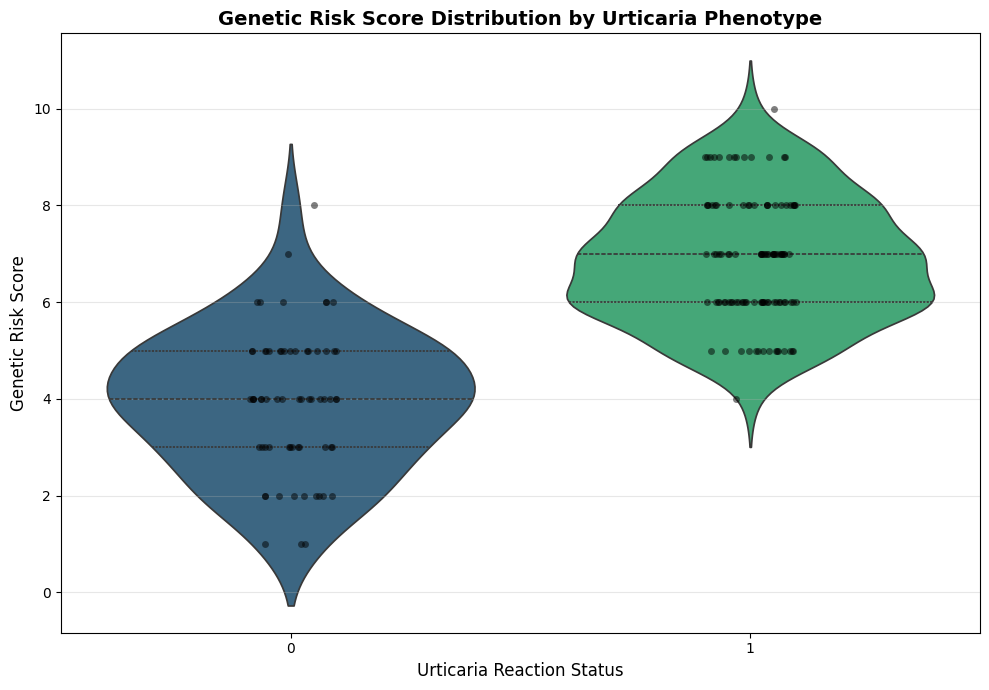

In [47]:
violin_plot(geno_pheno_df, 'reaction_urticaria', 'genetic_risk_score', 'Genetic Risk Score Distribution by Urticaria Phenotype', 'Urticaria Reaction Status', 'Genetic Risk Score')

## Severity Analysis


SNP rs6703348:
  Records before filtering: 179
  Records after filtering out -1: 156
  Records after numeric conversion: 156

SNP rs74227709:
  Records before filtering: 179
  Records after filtering out -1: 156
  Records after numeric conversion: 156

SNP rs35834008:
  Records before filtering: 179
  Records after filtering out -1: 156
  Records after numeric conversion: 156

SNP rs139299944:
  Records before filtering: 179
  Records after filtering out -1: 156
  Records after numeric conversion: 156

SNP rs73141533:
  Records before filtering: 179
  Records after filtering out -1: 156
  Records after numeric conversion: 156

SNP rs118070675:
  Records before filtering: 179
  Records after filtering out -1: 156
  Records after numeric conversion: 156


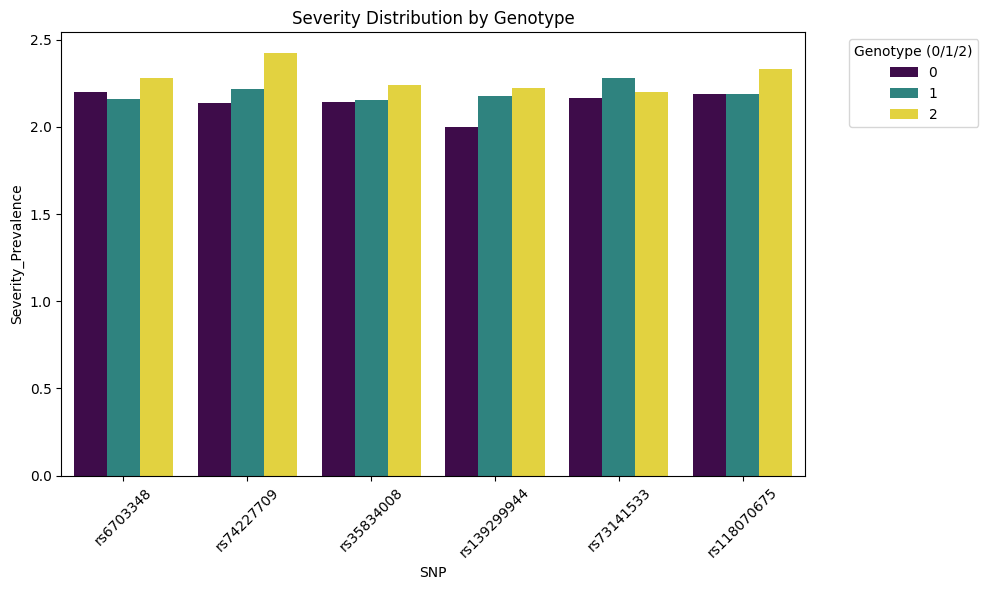

In [48]:
plot_severity_genotype(geno_pheno_df, snp_list)

### Ordinal Regression Analysis for each SNP

In [49]:
for snp_identifier in snp_list:
    ordinal_result = ordinal_regression(geno_pheno_df, snp_identifier, 'max_severity')
    if ordinal_result:
        print(f"SNP: {snp_identifier}")
        print(ordinal_result.summary())
        print()
    else:
        print(f"SNP: {snp_identifier} - Model fitting failed: {str(e)}")
        print()

SNP: rs6703348
                             OrderedModel Results                             
Dep. Variable:           max_severity   Log-Likelihood:                -191.17
Model:                   OrderedModel   AIC:                             390.3
Method:            Maximum Likelihood   BIC:                             403.1
Date:                Wed, 18 Feb 2026                                         
Time:                        21:23:49                                         
No. Observations:                 179                                         
Df Residuals:                     175                                         
Df Model:                           1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
rs6703348      0.4364      0.208      2.099      0.036       0.029       0.844
-1.0/1.0      -1.4944      0.295     

### Genetic Risk Score Ordinal Regression

In [50]:
risk_score_ordinal_result = ordinal_regression(geno_pheno_df, 'genetic_risk_score', 'max_severity')
if risk_score_ordinal_result:
    print("Genetic Risk Score → Max Severity Ordinal Regression Results:")
    print(risk_score_ordinal_result.summary())

    # Interpret the association
    risk_score_coefficient = risk_score_ordinal_result.params['genetic_risk_score']
    risk_score_p_value = risk_score_ordinal_result.pvalues['genetic_risk_score']

    print(f"\nInterpretation:")
    print(f"  Coefficient: {risk_score_coefficient:.4f}")
    print(f"  P-value: {risk_score_p_value:.4f}")

    if risk_score_p_value < 0.05:
        if risk_score_coefficient > 0:
            print("  → Higher genetic risk score associated with increased severity")
        else:
            print("  → Higher genetic risk score associated with decreased severity")
    else:
        print("  → No significant association detected")

Genetic Risk Score → Max Severity Ordinal Regression Results:
                             OrderedModel Results                             
Dep. Variable:           max_severity   Log-Likelihood:                -182.36
Model:                   OrderedModel   AIC:                             372.7
Method:            Maximum Likelihood   BIC:                             385.5
Date:                Wed, 18 Feb 2026                                         
Time:                        21:23:50                                         
No. Observations:                 179                                         
Df Residuals:                     175                                         
Df Model:                           1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
genetic_risk_score     0.3716      0.081      4.562  

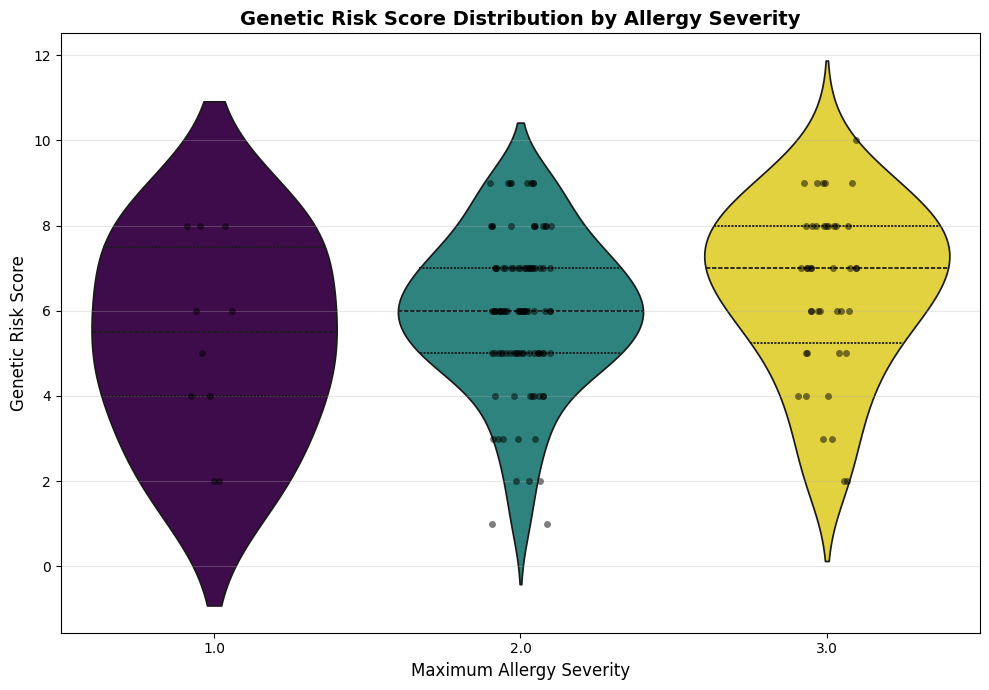

In [51]:
violin_plot(geno_pheno_df, 'max_severity', 'genetic_risk_score', 'Genetic Risk Score Distribution by Allergy Severity', 'Maximum Allergy Severity', 'Genetic Risk Score')

## Reaction Burden Analysis

In [52]:
correlation_coefficient, p_value = spearman_correlation_burden(geno_pheno_df)
print(f"Spearman correlation coefficient: {correlation_coefficient:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    if correlation_coefficient > 0:
        print("→ Significant positive correlation: Higher genetic risk associated with greater reaction burden")
    else:
        print("→ Significant negative correlation: Higher genetic risk associated with lower reaction burden")
else:
    print("→ No significant correlation detected")

Spearman correlation coefficient: 0.4694
P-value: 0.000000
→ Significant positive correlation: Higher genetic risk associated with greater reaction burden


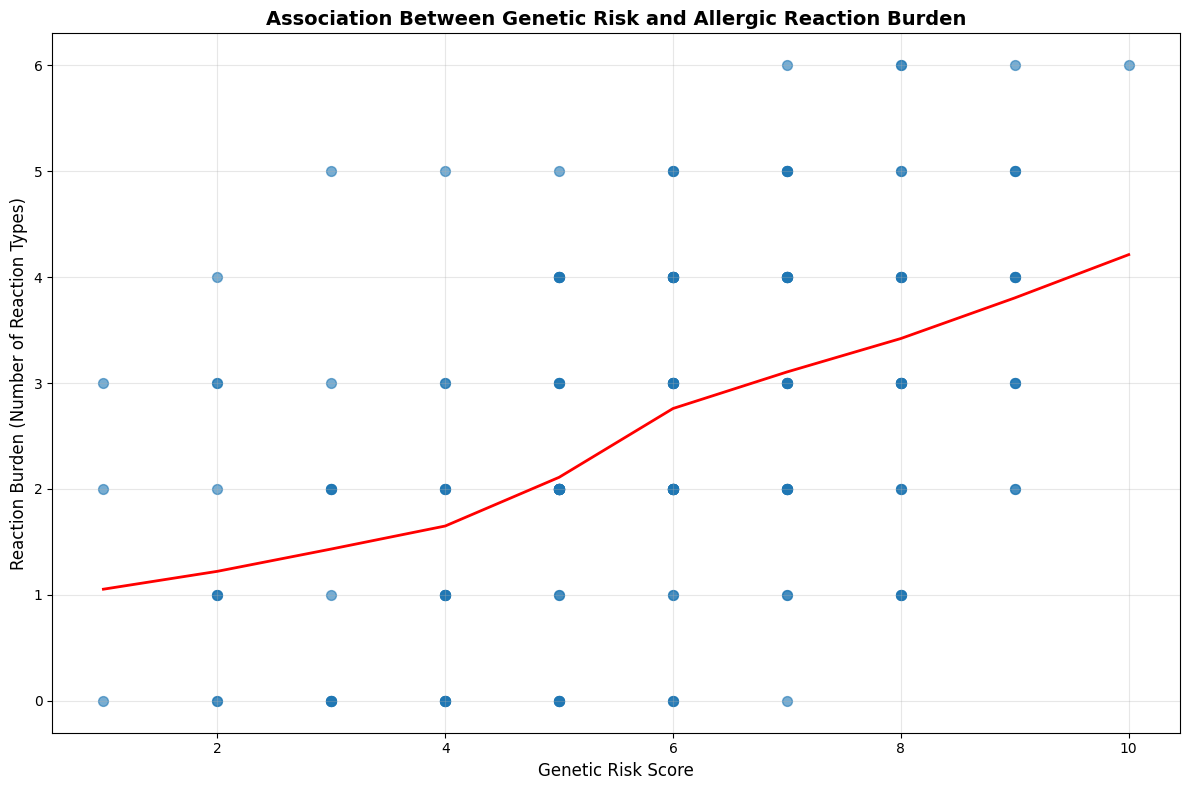

In [53]:
regplot(geno_pheno_df, "genetic_risk_score", "reaction_burden", "Association Between Genetic Risk and Allergic Reaction Burden", "Genetic Risk Score", "Reaction Burden (Number of Reaction Types)")

# Results
- Cohort Context
    - 179 patients


    - 794 allergy encounters


    - 6 SNPs evaluated, supported by literature


- Genotype–Phenotype Associations
    - 6/6 SNPs and genetic risk score significant for urticaria (logistic regression)


    - 6/6 SNPs and genetic risk score significant for increasing severity (ordinal model)


    - Genetic risk score correlated with reaction burden


# Limitations
- Synthetic data relied on controlled enrichment assumptions


- Moderate sample size (179 patients) reduces statistical power


- SNPs simulated independently - no linkage disequilibrium modeled


- EHR data analyzed at aggregated patient level - time-related sequence ignored


- Primary models not adjusted for additional covariates (age, gender, medications, living conditions, etc.)

- This project demonstrates analytical workflow design using synthetic data. Results are not intended as biological inference or clinical evidence
